In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("RELIANCE.csv")

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [3]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5306
Columns: 15


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Symbol              5306 non-null   object 
 2   Series              5306 non-null   object 
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4792 non-null   float64
 14  %Deliverble         4792 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 621.9

In [6]:
df.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2000-01-03 00:00:00
End date: 2021-04-30 00:00:00


In [10]:
df = df.sort_values("Date").reset_index(drop=True)

In [11]:
df.describe()

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2.456000e+03,4.792000e+03,4792.000000
mean,2010-08-18 21:26:56.132679936,1010.984866,1012.602375,1026.823803,996.886977,1011.157143,1011.316839,1011.937409,5.583028e+06,6.076715e+14,1.452306e+05,2.280885e+06,0.435039
min,2000-01-03 00:00:00,203.200000,205.500000,219.500000,197.150000,203.300000,203.200000,212.290000,5.282000e+04,4.295543e+12,2.991000e+03,2.909700e+04,0.076300
25%,2005-04-13 12:00:00,572.137500,572.925000,582.950000,564.237500,572.062500,572.512500,573.190000,2.836454e+06,2.203354e+14,7.215900e+04,1.194524e+06,0.323325
50%,2010-08-17 12:00:00,937.950000,939.000000,950.075000,927.550000,939.025000,938.275000,939.785000,4.213432e+06,3.662999e+14,1.021435e+05,1.810434e+06,0.449450
75%,2015-12-17 18:00:00,1247.387500,1247.675000,1267.350000,1227.450000,1248.287500,1248.275000,1247.375000,6.602604e+06,6.656490e+14,1.686702e+05,2.752935e+06,0.544300
max,2021-04-30 00:00:00,3220.850000,3298.000000,3298.000000,3141.300000,3223.000000,3220.850000,3197.750000,6.523089e+07,1.473434e+16,1.428490e+06,3.495888e+07,0.978300
std,NaN,570.987079,572.575893,581.986757,560.703328,570.938608,571.046753,571.222520,4.983793e+06,8.369739e+14,1.297557e+05,1.882665e+06,0.144722


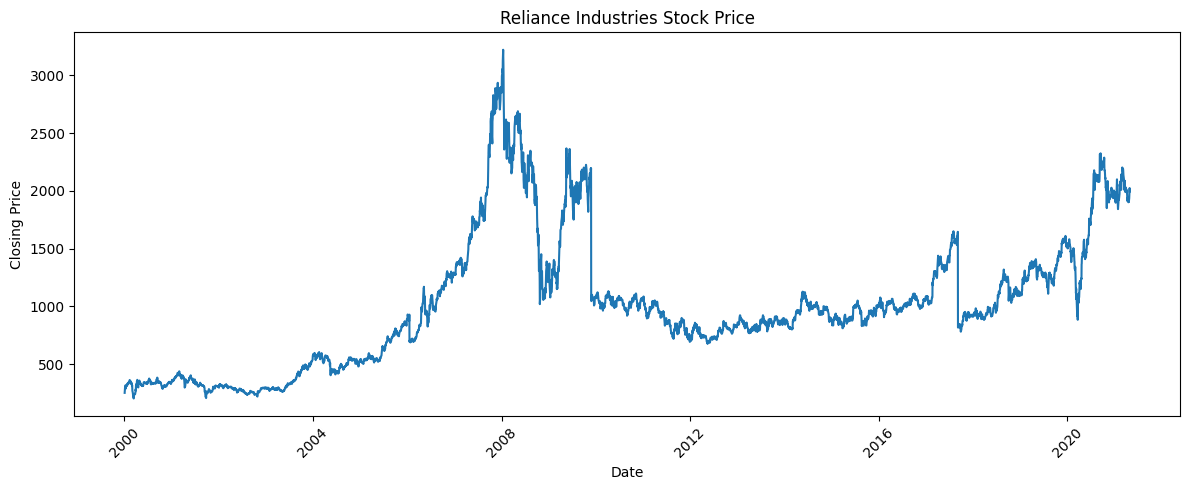

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"])

plt.title("Reliance Industries Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
df["Daily Return"] = df["Close"].pct_change() * 100

In [14]:
df[["Date", "Close", "Daily Return"]].head(10)

,Date,Close,Daily Return
0,2000-01-03,251.70,NaN
1,2000-01-04,271.85,8.005562
2,2000-01-05,282.50,3.917602
3,2000-01-06,294.35,4.194690
4,2000-01-07,314.55,6.862579
5,2000-01-10,308.50,-1.923383
6,2000-01-11,288.50,-6.482982
7,2000-01-12,301.70,4.575390
8,2000-01-13,311.85,3.364269
9,2000-01-14,316.30,1.426968


In [15]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

In [16]:
df[["Date", "Close", "MA20", "MA50"]].tail(10)

,Date,Close,MA20,MA50
5296,2021-04-16,1932.10,2003.5250,2041.516
5297,2021-04-19,1901.70,1995.8425,2041.034
5298,2021-04-20,1901.15,1990.4450,2040.444
5299,2021-04-22,1906.40,1981.6650,2040.086
5300,2021-04-23,1904.35,1973.7625,2039.698
5301,2021-04-26,1937.85,1966.2800,2039.426
5302,2021-04-27,1988.65,1963.3475,2040.076
5303,2021-04-28,1997.30,1963.6400,2040.536
5304,2021-04-29,2024.05,1965.1100,2039.903
5305,2021-04-30,1994.50,1963.3700,2038.961


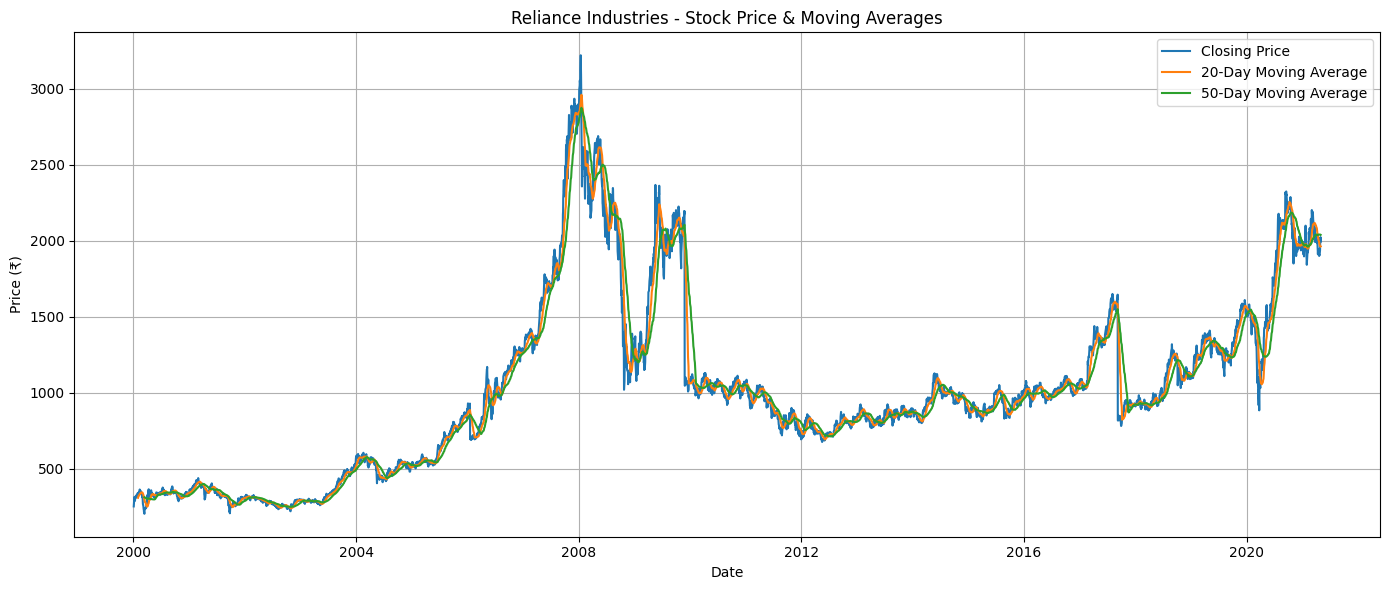

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Closing Price")
plt.plot(df["Date"], df["MA20"], label="20-Day Moving Average")
plt.plot(df["Date"], df["MA50"], label="50-Day Moving Average")

plt.title("Reliance Industries - Stock Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
df["Cumulative Return"] = (1 + df["Daily Return"] / 100).cumprod() - 1

In [19]:
df["Cumulative Return %"] = df["Cumulative Return"] * 100

In [20]:
df[["Date", "Cumulative Return %"]].tail()

,Date,Cumulative Return %
5301,2021-04-26,669.904648
5302,2021-04-27,690.087406
5303,2021-04-28,693.524037
5304,2021-04-29,704.151768
5305,2021-04-30,692.411601


In [21]:
df["Running Maximum"] = df["Close"].cummax()

df["Drawdown"] = (
    (df["Close"] - df["Running Maximum"])
    / df["Running Maximum"]
) * 100

In [22]:
max_drawdown = df["Drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2f}%")

Maximum Drawdown: -79.01%


In [23]:
total_return = (
    (df["Close"].iloc[-1] / df["Close"].iloc[0]) - 1
) * 100

average_daily_return = df["Daily Return"].mean()

annualized_volatility = df["Daily Return"].std() * np.sqrt(252)

highest_price = df["Close"].max()
lowest_price = df["Close"].min()

print("RELIANCE STOCK ANALYSIS")
print("-" * 30)
print(f"Start Date: {df['Date'].min().date()}")
print(f"End Date: {df['Date'].max().date()}")
print(f"Starting Price: ₹{df['Close'].iloc[0]:.2f}")
print(f"Latest Price: ₹{df['Close'].iloc[-1]:.2f}")
print(f"Highest Price: ₹{highest_price:.2f}")
print(f"Lowest Price: ₹{lowest_price:.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {average_daily_return:.4f}%")
print(f"Annualized Volatility: {annualized_volatility:.2f}%")
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

RELIANCE STOCK ANALYSIS
------------------------------
Start Date: 2000-01-03
End Date: 2021-04-30
Starting Price: ₹251.70
Latest Price: ₹1994.50
Highest Price: ₹3220.85
Lowest Price: ₹203.20
Total Return: 692.41%
Average Daily Return: 0.0707%
Annualized Volatility: 38.15%
Maximum Drawdown: -79.01%


In [26]:
monthly = df.set_index("Date")["Close"].resample("M").last()

In [27]:
monthly_return = monthly.pct_change() * 100

In [28]:
monthly_analysis = pd.DataFrame({
    "Month End Price": monthly,
    "Monthly Return %": monthly_return
})

monthly_analysis.tail(12)

,Month End Price,Monthly Return %
Date,,
2020-05-31,1464.40,-0.109141
2020-06-30,1704.10,16.368479
2020-07-31,2067.10,21.301567
2020-08-31,2080.70,0.657927
2020-09-30,2234.35,7.384534
2020-10-31,2054.50,-8.049321
2020-11-30,1929.80,-6.069603
2020-12-31,1985.30,2.875946
2021-01-31,1841.95,-7.220571


In [29]:
best_month = monthly_return.idxmax()
best_month_return = monthly_return.max()

worst_month = monthly_return.idxmin()
worst_month_return = monthly_return.min()

print(f"Best Month: {best_month.strftime('%B %Y')} ({best_month_return:.2f}%)")
print(f"Worst Month: {worst_month.strftime('%B %Y')} ({worst_month_return:.2f}%)")

Best Month: April 2020 (31.63%)
Worst Month: September 2017 (-51.03%)


In [30]:
yearly = df.set_index("Date")["Close"].resample("Y").last()

In [31]:
yearly_return = yearly.pct_change() * 100

yearly_analysis = pd.DataFrame({
    "Year End Price": yearly,
    "Yearly Return %": yearly_return
})

yearly_analysis

,Year End Price,Yearly Return %
Date,,
2000-12-31,338.95,NaN
2001-12-31,306.20,-9.662192
2002-12-31,297.95,-2.694317
2003-12-31,572.85,92.263803
2004-12-31,533.70,-6.834250
2005-12-31,889.30,66.629192
2006-12-31,1270.15,42.825818
2007-12-31,2882.70,126.957446
2008-12-31,1232.75,-57.236272


In [32]:
best_year = yearly_return.idxmax()
worst_year = yearly_return.idxmin()

print(
    f"Best Year: {best_year.year} "
    f"({yearly_return.loc[best_year]:.2f}%)"
)

print(
    f"Worst Year: {worst_year.year} "
    f"({yearly_return.loc[worst_year]:.2f}%)"
)

Best Year: 2007 (126.96%)
Worst Year: 2008 (-57.24%)


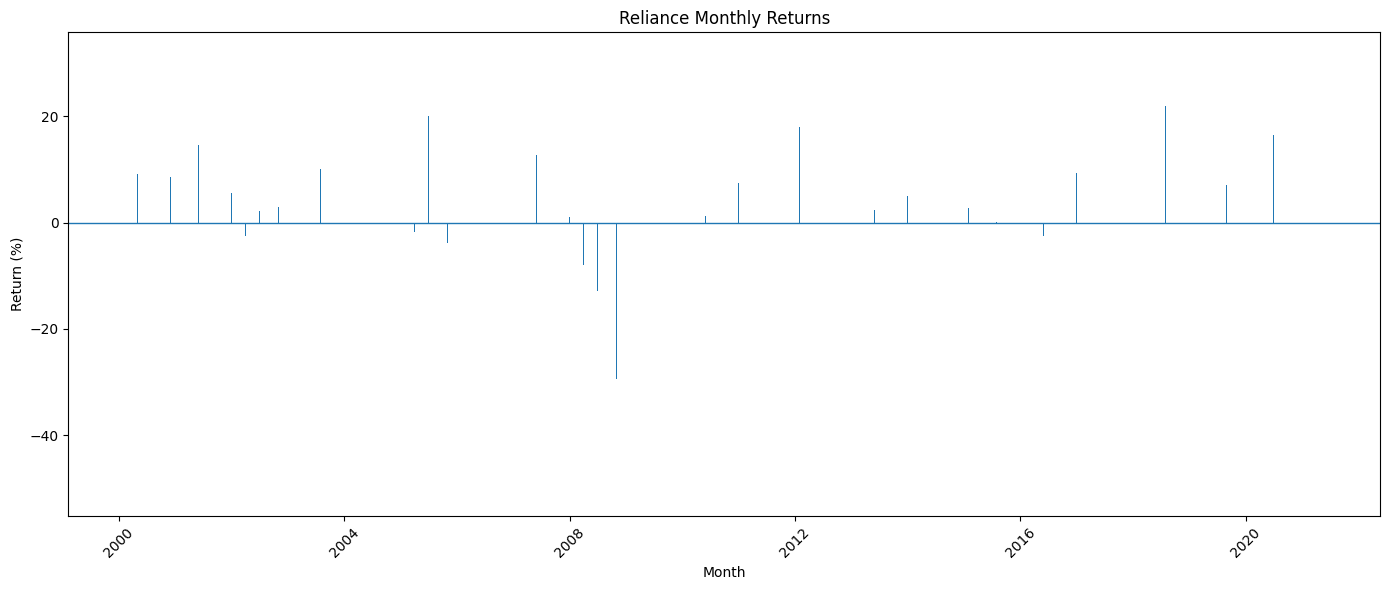

In [33]:
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_return.index,
    monthly_return.values
)

plt.axhline(0, linewidth=1)

plt.title("Reliance Monthly Returns")
plt.xlabel("Month")
plt.ylabel("Return (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

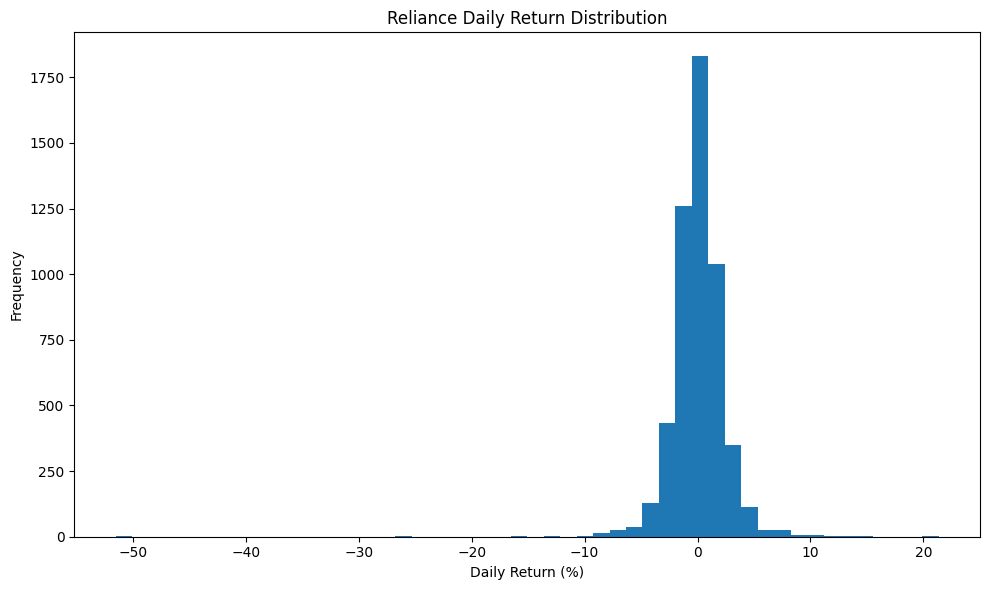

In [34]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Daily Return"].dropna(),
    bins=50
)

plt.title("Reliance Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Trading volume analysis

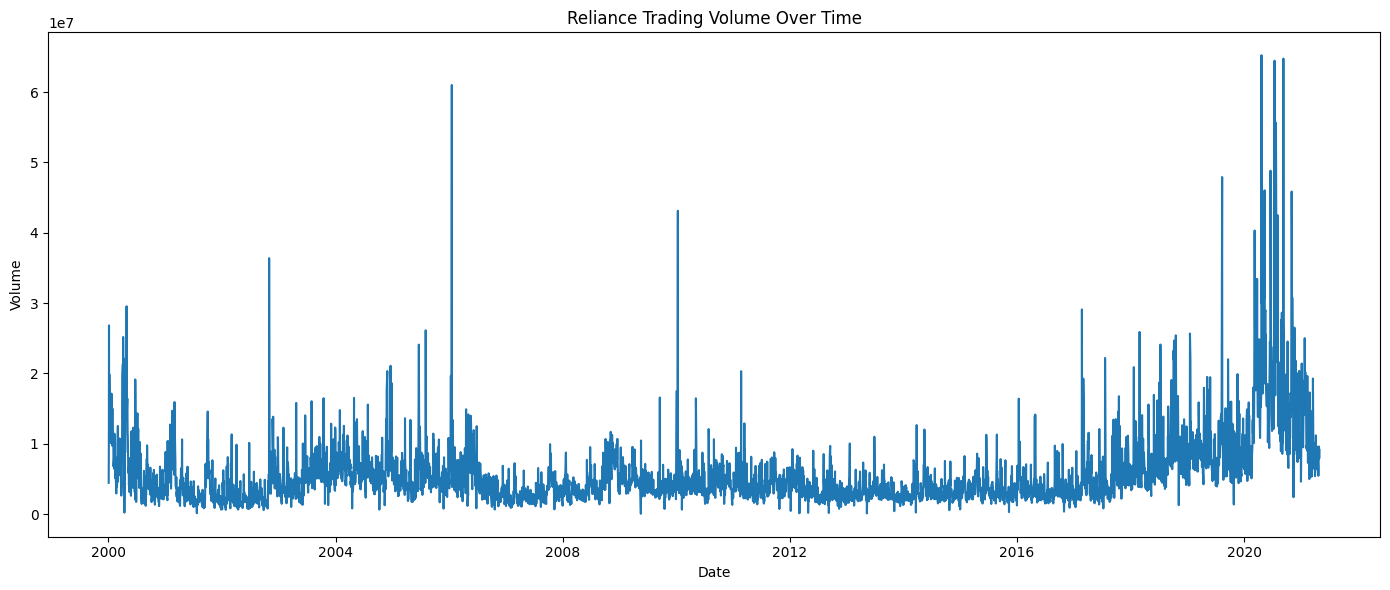

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Volume"]
)

plt.title("Reliance Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

In [36]:
highest_volume_day = df.loc[df["Volume"].idxmax()]

print("Highest Volume Day:")
print(highest_volume_day[["Date", "Close", "Volume"]])

Highest Volume Day:
Date      2020-04-22 00:00:00
Close                  1363.6
Volume               65230894
Name: 5049, dtype: object


In [37]:
df.to_csv("RELIANCE_analyzed.csv", index=False)

print("Analyzed dataset saved successfully!")

Analyzed dataset saved successfully!
